In [147]:
import pandas as pd

In [148]:
folder = "/home/nsrikant/BehaviorBoxNew/analysis/ad_hoc/trend_outputs"

In [149]:
models = ["6.9b", "160m"]
trends = ["increasing", "increase-decrease", "increase-stagnate"]

In [150]:
model_names1 = [
        "pythia-6_9b-step1",
        "pythia-6_9b-step2",
        "pythia-6_9b-step4",
        "pythia-6_9b-step8",
        "pythia-6_9b-step16",
        "pythia-6_9b-step32",
        "pythia-6_9b-step64",
        "pythia-6_9b-step128",
        "pythia-6_9b-step256",
        "pythia-6_9b-step512",
        "pythia-6_9b-step1000",
        "pythia-6_9b-step10000",
        "pythia-6_9b-step70000",
        "pythia-6_9b-step100000",
        "pythia-6_9b"
    ]

model_names2 = [
        "pythia-160m-step1",
        "pythia-160m-step2",
        "pythia-160m-step4",
        "pythia-160m-step8",
        "pythia-160m-step16",
        "pythia-160m-step32",
        "pythia-160m-step64",
        "pythia-160m-step128",
        "pythia-160m-step256",
        "pythia-160m-step512",
        "pythia-160m-step1000",
        "pythia-160m-step10000",
        "pythia-160m-step70000",
        "pythia-160m-step100000",
        "pythia-160m"
    ]

for model in models:
    print(model)
    for trend in trends:
        if model == "6.9b":
            model_names = model_names1
        else:
            model_names = model_names2
        print(trend)
        file_path = f"{folder}/Pythia{model}/{trend}/acquired_features.csv"
        df = pd.read_csv(file_path)
        print("Early->")
        early = [model_names[i] for i in [6,7,8]]
        late = [model_names[i] for i in [-2,-1]]
        early_df = df[df["Acquired At"].isin(early)]
        late_df = df[df["Acquired At"].isin(late)]
        # print(early_df)
        print("\n".join(early_df["Description"].tolist()))
        print("Late->")
        print("\n".join(late_df["Description"].tolist()))
        # print(late_df)
        print()
    print()
    print()


6.9b
increasing
Early->
Whitespace or asterisks appearing between mathematical terms in algebraic expressions and calculus problems
Late->
Programming syntax elements including CSS properties, HTML attributes, XML tags, and code variables
Past participles and other terms used to introduce or reference visual elements, data, and findings in technical and scientific writing.
Spaces that appear before comment delimiters (//) in code, representing consistent formatting in programming contexts.
Single-digit numbers appearing within base64-encoded strings and cryptographic data
All instances are the modal verb "may" expressing possibility or uncertainty.
Medical terminology and anatomical structures used in clinical and research contexts.

increase-decrease
Early->
Negative contractions with "n't" suffix
Tab characters followed by multiple spaces, representing consistent code indentation patterns in programming contexts.
Late->


increase-stagnate
Early->
All instances represent a space char

In [151]:
trends = ["increasing", "increase-stagnate"]
for model in models:
    print("Pythia: ", model)
    for trend in trends:
        print(trend)
        file_path = f"{folder}/Pythia{model}/{trend}/not_acquired_features.csv"
        try:
            df = pd.read_csv(file_path)
        except:
            continue
        print("Almost Acquired->")
        print("\n".join(df["Description"].tolist()[:5]))
        print()
        print("Far from being Acquired->")
        print("\n".join(df["Description"].tolist()[-5:]))
        print()
    print()
    print()


Pythia:  6.9b
increasing
Almost Acquired->
Coordinating conjunctions connecting clauses or phrases in compound sentences.
Nouns referring to specific roles or parties in legal, business, and formal contractual relationships
Programming and web development terminology including technical concepts like classes, events, declarations, and code elements.
All instances of the word "things" (and one "stuff") used as a general noun to refer to objects, activities, or concepts in various contexts.
Mathematical variables and expressions in LaTeX format within academic/scientific text.

Far from being Acquired->
Incomplete contractions where "don't", "doesn't", and "didn't" are split across formatting boundaries
Words related to requesting, inquiring, or seeking information from someone.
Verbs related to problem-solving and understanding through analysis or investigation
Discourse markers or transitional words used to connect ideas and indicate logical relationships between sentences or clauses.


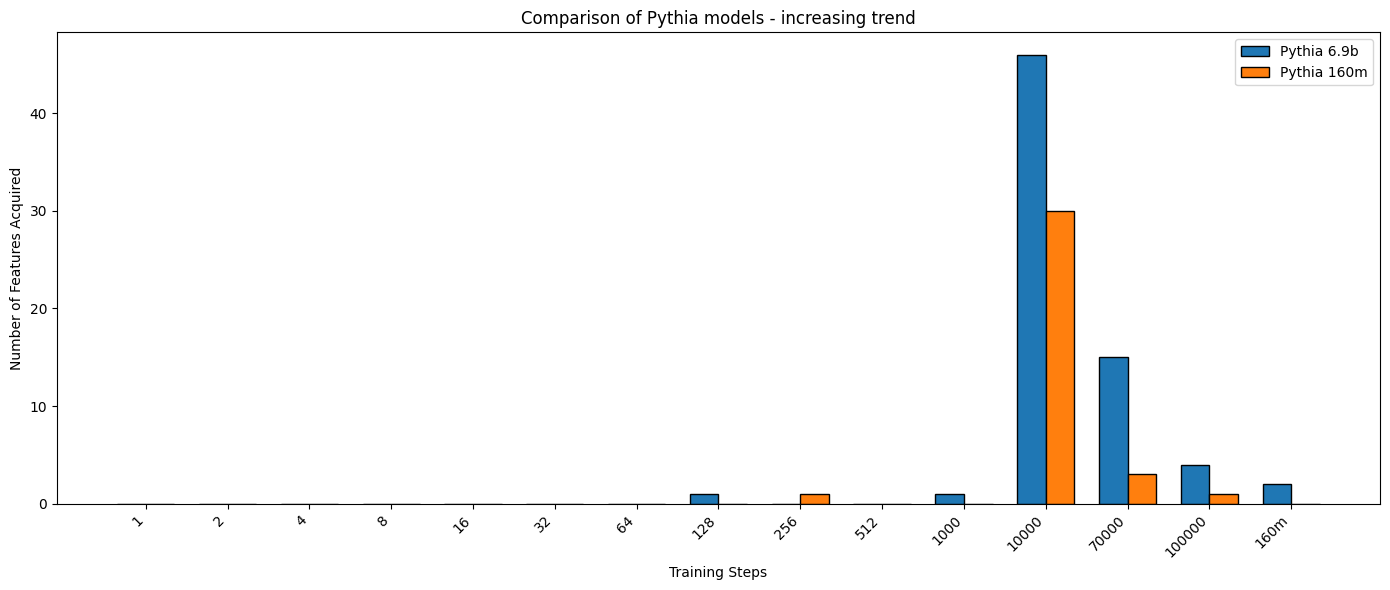

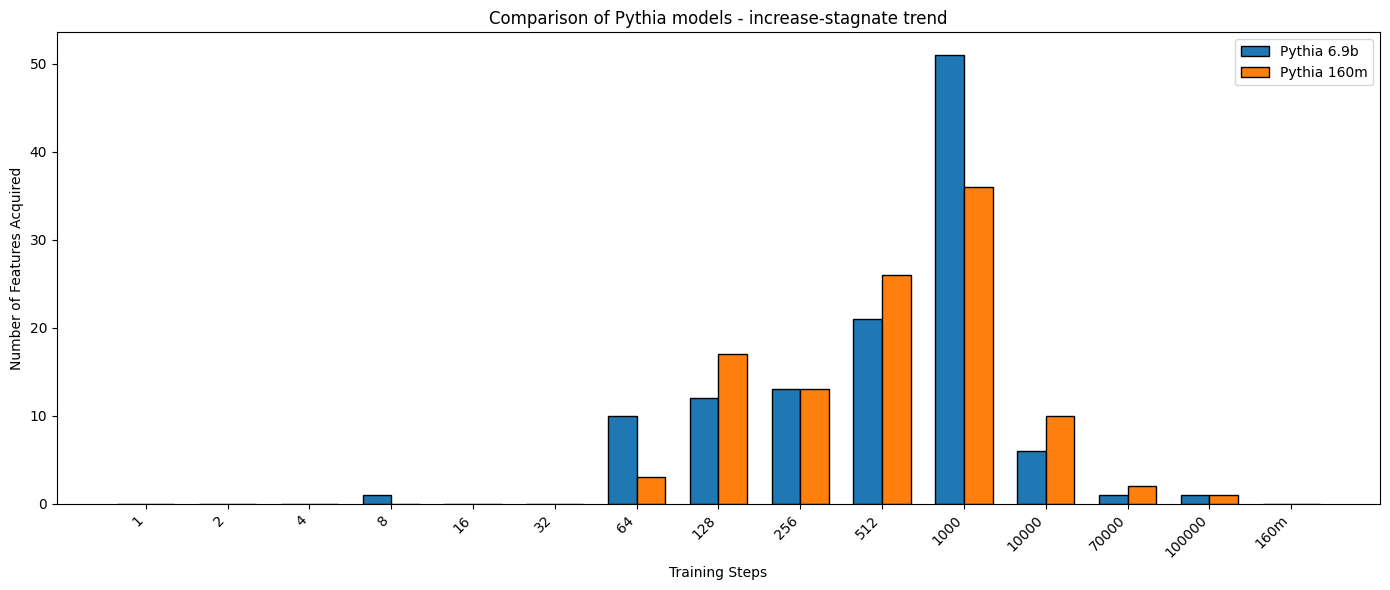

In [157]:
model_names1 = [
        "pythia-6_9b-step1",
        "pythia-6_9b-step2",
        "pythia-6_9b-step4",
        "pythia-6_9b-step8",
        "pythia-6_9b-step16",
        "pythia-6_9b-step32",
        "pythia-6_9b-step64",
        "pythia-6_9b-step128",
        "pythia-6_9b-step256",
        "pythia-6_9b-step512",
        "pythia-6_9b-step1000",
        "pythia-6_9b-step10000",
        "pythia-6_9b-step70000",
        "pythia-6_9b-step100000",
        "pythia-6_9b"
    ]

model_names2 = [
        "pythia-160m-step1",
        "pythia-160m-step2",
        "pythia-160m-step4",
        "pythia-160m-step8",
        "pythia-160m-step16",
        "pythia-160m-step32",
        "pythia-160m-step64",
        "pythia-160m-step128",
        "pythia-160m-step256",
        "pythia-160m-step512",
        "pythia-160m-step1000",
        "pythia-160m-step10000",
        "pythia-160m-step70000",
        "pythia-160m-step100000",
        "pythia-160m"
    ]


import matplotlib.pyplot as plt


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Example: trends and models
# trends = ["increasing", "increase-decrease", "increase-stagnate"]
# models = ["6.9b", "160m"]


trends = ["increasing", "increase-stagnate"]
for trend in trends:
    plt.figure(figsize=(14,6))

    bar_width = 0.35
    x = np.arange(len(model_names))  # positions for x-axis

    for i, model in enumerate(models):
        if model == "6.9b":
            model_names = model_names1
        else:
            model_names = model_names2
        file_path = f"{folder}/Pythia{model}/{trend}/acquired_features.csv"
        df = pd.read_csv(file_path)
        
        # Count features per checkpoint
        acq_counts = df.groupby("Acquired At").size()

        # Reindex to ensure all checkpoints exist and are in the correct order
        acq_counts = acq_counts.reindex(model_names, fill_value=0)

        # Shift x positions for side-by-side bars
        plt.bar(x + i*bar_width, acq_counts.values, 
                width=bar_width, label=f"Pythia {model}", edgecolor='black')
    model_names = [model_name.split("-")[-1].strip("step") for model_name in model_names]
    plt.xticks(x + bar_width/2, model_names, rotation=45, ha='right')
    plt.xlabel("Training Steps")
    plt.ylabel("Number of Features Acquired")
    plt.title(f"Comparison of Pythia models - {trend} trend")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{folder}/comparison_pythia_models_{trend}.png")


In [153]:
model_names1 = [
        "pythia-6_9b-step1",
        "pythia-6_9b-step2",
        "pythia-6_9b-step4",
        "pythia-6_9b-step8",
        "pythia-6_9b-step16",
        "pythia-6_9b-step32",
        "pythia-6_9b-step64",
        "pythia-6_9b-step128",
        "pythia-6_9b-step256",
        "pythia-6_9b-step512",
        "pythia-6_9b-step1000",
        "pythia-6_9b-step10000",
        "pythia-6_9b-step70000",
        "pythia-6_9b-step100000",
        "pythia-6_9b"
    ]

model_names2 = [
        "pythia-160m-step1",
        "pythia-160m-step2",
        "pythia-160m-step4",
        "pythia-160m-step8",
        "pythia-160m-step16",
        "pythia-160m-step32",
        "pythia-160m-step64",
        "pythia-160m-step128",
        "pythia-160m-step256",
        "pythia-160m-step512",
        "pythia-160m-step1000",
        "pythia-160m-step10000",
        "pythia-160m-step70000",
        "pythia-160m-step100000",
        "pythia-160m"
    ]


import matplotlib.pyplot as plt


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Example: trends and models
# trends = ["increasing", "increase-decrease", "increase-stagnate"]
# models = ["6.9b", "160m"]


trends = ["increasing"]
for trend in trends:
    plt.figure(figsize=(14,6))

    bar_width = 0.35
    x = np.arange(len(model_names))  # positions for x-axis

    for i, model in enumerate(models):
        if model == "6.9b":
            model_names = model_names1
        else:
            model_names = model_names2
        file_path = f"{folder}/Pythia{model}/{trend}/acquired_features.csv"
        try:
            df = pd.read_csv(file_path)
        except:
            continue
        
        

<Figure size 1400x600 with 0 Axes>

In [154]:
def calculate_specificity(feature):
    """Calculate feature specificity"""
    subset_correlations = feature.get('subset_correlations', {})
    
    if not subset_correlations:
        return None, None, {}
    
    subset_corrs = {}
    for subset_name, corr_data in subset_correlations.items():
        residual_corr = corr_data.get('residual_pearson_correlation')
        raw_corr = corr_data.get('raw_pearson_correlation')
        corr_to_use = residual_corr
        
        if corr_to_use is not None:
            subset_corrs[subset_name] = abs(corr_to_use)
    
    if len(subset_corrs) < 2:
        return None, None, subset_corrs
    
    corr_values = list(subset_corrs.values())
    max_corr = np.max(corr_values)
    mean_corr = np.mean(corr_values)
    
    specificity = max_corr - mean_corr
    specificity_ratio = max_corr / (mean_corr + 0.01)
    
    return specificity, specificity_ratio, subset_corrs

def calculate_max_corr(feature):
    """Calculate feature specificity"""
    subset_correlations = feature.get('subset_correlations', {})
    
    if not subset_correlations:
        return None, None
    
    subset_corrs = {}
    for subset_name, corr_data in subset_correlations.items():
        residual_corr = corr_data.get('residual_pearson_correlation')
        raw_corr = corr_data.get('raw_pearson_correlation')
        corr_to_use = residual_corr
        
        if corr_to_use is not None:
            subset_corrs[subset_name] = abs(corr_to_use)
    

    subset_names = list(subset_correlations.keys())
    corr_values = list(subset_corrs.values())
    max_corr_index = np.argmax(corr_values)
    
    
    return subset_names[max_corr_index], corr_values[max_corr_index]

In [12]:
# features_file = "/home/nsrikant/BehaviorBoxNew/analysis/precomputed_data_blimp_full/Pythia-piletrainedonpile.json"
features_file = "/home/nsrikant/BehaviorBoxNew/analysis/precomputed_data_blimp_full/Pythia6.9b-piletrainedonpile.json"


import json
import pandas as pd
import numpy as np



In [13]:
with open(features_file, 'r') as f:
    features_data = json.load(f)
features_list = features_data.get('features', [])


In [14]:
features_df = pd.DataFrame(features_list)
features_df.head()

,feature_id,description,winning_rank,model,sample_centroid_cos_sim,avg_ranks,avg_probs,median_probs,lower_errors,higher_errors,...,feat_perf_vs_overall_residual_pearson,feat_perf_vs_overall_residual_spearman,has_performance_data,subset_counts,subset_good_counts,subset_bad_counts,good_count,bad_count,subset_correlations,samples
0,1863,"Negative contractions with ""n't"" suffix",1,pythia-6_9b-step128,0.8867,"[13.0, 13.090909090909092, 12.636363636363637,...","[3.70964831e-06, 3.70837509e-06, 3.72201874e-0...","[3.71639621e-06, 3.69115876e-06, 3.49366253e-0...","[8.478224186871602e-07, 8.478596126404003e-07,...","[9.28074918686961e-06, 9.269639221995474e-06, ...",...,None,None,False,{'': 11},{},{},0,0,{'determiner_noun_agreement_1': {'raw_pearson_...,"[{'word_id': 'index_115222305_981', 'activatio..."
1,294,"Tab characters followed by multiple spaces, re...",1,pythia-6_9b-step128,0.9575,"[14.92, 13.96, 13.0, 6.06, 11.0, 6.18, 6.2, 1....","[1.60559263e-05, 1.75971651e-05, 6.99474645e-0...","[1.36202311e-05, 1.49416276e-05, 6.31159074e-0...","[1.5485331369827081e-06, 1.544041342758366e-06...","[3.9494656682535814e-05, 4.329262473510938e-05...",...,None,None,False,{'': 50},{},{},0,0,{'determiner_noun_agreement_1': {'raw_pearson_...,"[{'word_id': 'index_54672459_1316', 'activatio..."
2,2132,All instances refer to probability problems in...,1,pythia-6_9b-step256,0.9750,"[9.0, 10.0, 11.0, 13.34, 15.0, 13.66, 12.0, 8....","[6.12977644e-06, 6.08007813e-06, 5.3173464e-06...","[6.02417316e-06, 5.97031884e-06, 5.22759172e-0...","[4.933012887695051e-06, 4.875918185287362e-06,...","[8.905900018342137e-06, 8.84599511636641e-06, ...",...,None,None,False,{'': 50},{},{},0,0,{'determiner_noun_agreement_1': {'raw_pearson_...,"[{'word_id': 'index_30173755_785', 'activation..."
3,2987,Mathematical probability problems involving sa...,1,pythia-6_9b-step256,0.9830,"[9.06, 10.02, 10.98, 13.22, 14.88, 13.78, 12.0...","[6.34513446e-06, 6.29437672e-06, 5.54851371e-0...","[6.09930892e-06, 6.04055479e-06, 5.28193618e-0...","[4.9634692848937315e-06, 4.927821866461029e-06...","[1.1345426329467969e-05, 1.1379093431919627e-0...",...,None,None,False,{'': 50},{},{},0,0,{'determiner_noun_agreement_1': {'raw_pearson_...,"[{'word_id': 'index_30173755_577', 'activation..."
4,2295,All instances represent dialogue formatting wh...,1,pythia-6_9b-step512,0.9272,"[15.0, 14.0, 13.0, 12.0, 11.0, 10.0, 3.68, 7.8...","[7.11869309e-06, 7.19503809e-06, 8.47674923e-0...","[6.509589e-06, 6.56389453e-06, 7.87005494e-06,...","[4.295454997459472e-06, 4.354780399254876e-06,...","[2.3428436025915386e-05, 2.3659004464348397e-0...",...,None,None,False,{'': 50},{},{},0,0,{'determiner_noun_agreement_1': {'raw_pearson_...,"[{'word_id': 'index_4163603_1296', 'activation..."


In [108]:

features_df["specificity_ratio"] = features_df.apply(
    lambda row: calculate_specificity(row)[1], axis=1)

features_df["specificity"] = features_df.apply(
    lambda row: calculate_specificity(row)[0], axis=1)

In [109]:
features_df[["max_corr_subset", "max_corr_value"]] = features_df.apply(
    lambda row: pd.Series(calculate_max_corr(row)), axis=1)

In [110]:
features_df["mean_median_prob"] = features_df["median_probs"].apply(lambda x: np.mean(x).round(4))
features_df["max_median_prob"] = features_df["median_probs"].apply(lambda x: np.max(x).round(4))

In [111]:
features_df["specificity_ratio"].sort_values(ascending=False).head(10)

177    1.690546
199    1.682120
51     1.677425
133    1.654104
75     1.651828
82     1.626512
64     1.623661
78     1.621813
227    1.598866
29     1.597864
Name: specificity_ratio, dtype: float64

In [112]:
features_df.sort_values(by="specificity", ascending=False)[["mean_median_prob", "max_median_prob", "specificity", "description"]].head()

,mean_median_prob,max_median_prob,specificity,description
75,0.4103,0.9989,0.379068,Asterisks appearing in code comment formatting...
177,0.4223,0.9993,0.378971,Colons appearing in code documentation and com...
199,0.4381,0.9992,0.374532,HTML closing tags and bracket symbols appearin...
20,0.2599,0.7266,0.352657,"The word ""Is"" appearing at the beginning of ma..."
133,0.2093,0.5433,0.345408,Adjectives used in mathematical comparison que...


In [113]:
features_df.sort_values(by="max_corr_value", ascending=False)[["mean_median_prob", "max_median_prob", "specificity", "description", "max_corr_subset", "max_corr_value"]].head(20)

,mean_median_prob,max_median_prob,specificity,description,max_corr_subset,max_corr_value
59,0.3136,0.9998,0.206039,"Numbers appearing in legal citations, footnote...",determiner_noun_agreement_with_adj_2,0.998424
96,0.2895,0.9519,0.188802,"Time duration expressions using ""year"" or ""yea...",determiner_noun_agreement_with_adjective_1,0.998345
94,0.3064,0.9885,0.204345,Variable names and function references in mixe...,determiner_noun_agreement_with_adj_2,0.997754
196,0.3011,0.9601,0.194971,Programming language keywords that define meth...,determiner_noun_agreement_with_adjective_1,0.997525
198,0.3101,0.9919,0.199870,"All instances show the preposition ""by"" preced...",determiner_noun_agreement_with_adj_2,0.996624
222,0.1609,0.4711,0.230071,Contractions representing auxiliary verbs and ...,determiner_noun_agreement_2,0.996577
181,0.3017,0.9948,0.199064,Words that function as part of compound adject...,determiner_noun_agreement_with_adj_2,0.996302
45,0.3019,0.9915,0.195866,"LaTeX commands, markup syntax elements, and HT...",determiner_noun_agreement_with_adj_2,0.996217
106,0.3050,0.9583,0.195168,LaTeX backslash command markers appearing in v...,determiner_noun_agreement_with_adj_2,0.996066
185,0.3365,0.9471,0.276942,"All instances refer to ""cells"" as a biological...",determiner_noun_agreement_1,0.995435


In [101]:
features_df.sort_values(by="max_corr_value", ascending=False)["description"].tolist()[:20]

['Time duration expressions using "year" or "years" as units of measurement.',
 'All instances show the preposition "by" preceded by a space in various technical documentation, code comments, and text contexts.',
 'Numbers appearing in legal citations, footnote references, and academic text formatting within formal documents.',
 'LaTeX backslash command markers appearing in various document contexts including code snippets, mathematical expressions, and programming output',
 'Variable names and function references in mixed mathematical and programming contexts',
 'Programming language keywords that define method visibility, return types, and control flow structures in various programming languages',
 'Words that function as part of compound adjectives or measurements, typically hyphenated with numbers to describe distances, time periods, or positions in sports and legal contexts.',
 'Mathematical expressions and calculations involving the decimal number zero or values with leading zero

In [102]:
features_df.sort_values(by="specificity", ascending=False)["description"].tolist()[:20]

['Asterisks appearing in code comment formatting, specifically as part of multi-line comment syntax in various programming languages.',
 'Colons appearing in code documentation and comment blocks, typically marking the end of labels or separating documentation sections.',
 'HTML closing tags and bracket symbols appearing at the end of XML/HTML elements or code blocks.',
 'The word "Is" appearing at the beginning of mathematical questions asking about numerical properties, comparisons, or classifications.',
 'Adjectives used in mathematical comparison questions to find the value most similar to a given target number.',
 'JSON/data structure field names or properties appearing in configuration files, APIs, or structured data formats.',
 'Colons used as separators in time expressions (hours and minutes).',
 'Reference markers for figures and sections in academic documents, typically used in citation and cross-referencing systems.',
 'LaTeX fraction commands (\\frac) used in mathematical e

In [4]:
import os
import scipy.stats as stats
def load_subset_performance_data(model_names, correlation_folder, performance_dataset_name):

    subset_performance_data = {}
    
    for model_name in model_names:
        perf_file = os.path.join(correlation_folder, model_name, 
                                f"{performance_dataset_name}_summary_seq_logprob.json")
        
        if not os.path.exists(perf_file):
            subset_performance_data[model_name] = {}
            continue
        
        
        with open(perf_file, 'r') as f:
            perf_data = json.load(f)
        subset_acc = {}
        
        for subset_name, score in perf_data["per_split_accuracy"].items():
            subset_acc[subset_name] = float(score)
            
    
        subset_performance_data[model_name] = subset_acc
        
       
    
    return subset_performance_data

def calculate_subset_correlations(feature_performance, model_names, subset_performance_data):
    """Calculate both RAW and RESIDUAL correlations for subsets"""
    
    subset_correlations = {}
    
    # Filter out None values from feature_performance
    valid_indices = [i for i, fp in enumerate(feature_performance) 
                    if fp is not None and i < len(model_names)]
    
    
    valid_feature_perf = [feature_performance[i] for i in valid_indices]
    valid_model_names = [model_names[i] for i in valid_indices]
    
    # Get all subsets available
    all_subsets = set()
    for model_name in valid_model_names:
        subset_data = subset_performance_data.get(model_name, {})
        all_subsets.update(subset_data.keys())
    
    
    # Correlate feature with each subset
    for subset in all_subsets:
        subset_perf_values = []
        
        for model_name in valid_model_names:
            subset_data = subset_performance_data.get(model_name, {})
            subset_acc = subset_data.get(subset)
            subset_perf_values.append(subset_acc)
            
            
        # RAW CORRELATION
        raw_pearson_corr, _ = stats.pearsonr(valid_feature_perf, subset_perf_values)
        raw_spearman_corr, _ = stats.spearmanr(valid_feature_perf, subset_perf_values)
        
        subset_correlations[subset] = {
            'raw_pearson_correlation': raw_pearson_corr.item() if hasattr(raw_pearson_corr, 'item') else 0,
            'raw_spearman_correlation': raw_spearman_corr.item() if hasattr(raw_spearman_corr, 'item') else 0
        }
        
            
    return subset_correlations



In [8]:
correlation_folder = f"/home/nsrikant/BehaviorBoxNew/results/blimp_full"

model_names1 = [
        "pythia-6_9b-step1",
        "pythia-6_9b-step2",
        "pythia-6_9b-step4",
        "pythia-6_9b-step8",
        "pythia-6_9b-step16",
        "pythia-6_9b-step32",
        "pythia-6_9b-step64",
        "pythia-6_9b-step128",
        "pythia-6_9b-step256",
        "pythia-6_9b-step512",
        "pythia-6_9b-step1000",
        "pythia-6_9b-step10000",
        "pythia-6_9b-step70000",
        "pythia-6_9b-step100000",
        "pythia-6_9b"
    ]

model_names2 = [
        "pythia-160m-step1",
        "pythia-160m-step2",
        "pythia-160m-step4",
        "pythia-160m-step8",
        "pythia-160m-step16",
        "pythia-160m-step32",
        "pythia-160m-step64",
        "pythia-160m-step128",
        "pythia-160m-step256",
        "pythia-160m-step512",
        "pythia-160m-step1000",
        "pythia-160m-step10000",
        "pythia-160m-step70000",
        "pythia-160m-step100000",
        "pythia-160m"
    ]

model = "160m"
if model == "6.9b":
    model_names = model_names1
    features_file = "/home/nsrikant/BehaviorBoxNew/analysis/precomputed_data_blimp_full/Pythia6.9b-piletrainedonpile.json"

else:
    model_names = model_names2
    features_file = "/home/nsrikant/BehaviorBoxNew/analysis/precomputed_data_blimp_full/Pythia-piletrainedonpile.json"

with open(features_file, 'r') as f:
    features_data = json.load(f)

features_list = features_data.get('features', [])
subset_performance_data = load_subset_performance_data(
       model_names, 
       correlation_folder, 
       "blimp_full"
   )


subset_corr_results_pearson = {}
subset_corr_results_spearman = {}
for feat in features_list:
    median_probs = feat['median_probs']
    subset_corr_results = calculate_subset_correlations(
                    median_probs,
                    model_names,
                    subset_performance_data
                )
    for subset in subset_corr_results:
        if subset not in subset_corr_results_pearson:
            subset_corr_results_pearson[subset] = []
            subset_corr_results_spearman[subset] = []
            
        
        subset_corr_results_pearson[subset].append(
            subset_corr_results[subset]['raw_pearson_correlation']
        )
        subset_corr_results_spearman[subset].append(
            subset_corr_results[subset]['raw_spearman_correlation']
        )

subset_corr_df_pearson = pd.DataFrame(subset_corr_results_pearson)
subset_corr_df_spearman = pd.DataFrame(subset_corr_results_spearman)


/tmp/ipykernel_4186530/478606128.py:61: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  raw_pearson_corr, _ = stats.pearsonr(valid_feature_perf, subset_perf_values)
/tmp/ipykernel_4186530/478606128.py:62: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  raw_spearman_corr, _ = stats.spearmanr(valid_feature_perf, subset_perf_values)


In [9]:
subset_corr_df_pearson.describe().T.sort_values(by="mean", ascending=False).index[:5]

Index(['irregular_plural_subject_verb_agreement_2', 'transitive',
       'irregular_plural_subject_verb_agreement_1',
       'determiner_noun_agreement_with_adj_irregular_2', 'ellipsis_n_bar_2'],
      dtype='object')

In [10]:
subset_corr_df_pearson.describe().T.sort_values(by="mean", ascending=False).index[-5:]

Index(['left_branch_island_echo_question', 'principle_A_c_command',
       'existential_there_quantifiers_2', 'left_branch_island_simple_question',
       'sentential_subject_island'],
      dtype='object')

In [199]:
subset_corr_df_spearman.describe()

,superlative_quantifiers_1,animate_subject_passive,coordinate_structure_constraint_complex_left_branch,irregular_past_participle_verbs,irregular_plural_subject_verb_agreement_1,npi_present_2,left_branch_island_echo_question,wh_vs_that_with_gap_long_distance,existential_there_quantifiers_2,passive_2,...,existential_there_subject_raising,intransitive,tough_vs_raising_2,matrix_question_npi_licensor_present,determiner_noun_agreement_irregular_1,coordinate_structure_constraint_object_extraction,determiner_noun_agreement_with_adj_irregular_2,wh_questions_object_gap,sentential_negation_npi_licensor_present,determiner_noun_agreement_with_adj_2
count,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,...,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000
mean,0.854701,0.906250,0.287499,0.794019,0.738346,-0.473085,0.733007,0.450118,-0.297662,0.883706,...,0.882637,0.648578,0.792902,0.014647,0.739527,0.820926,0.719673,-0.096202,0.398034,0.862932
std,0.072125,0.069320,0.098015,0.077166,0.090567,0.078719,0.066285,0.116518,0.069838,0.064951,...,0.071894,0.105117,0.089364,0.120659,0.089803,0.095053,0.087353,0.108813,0.096088,0.082993
min,0.153571,0.201966,-0.581396,0.098302,-0.184093,-0.882143,0.357143,-0.462914,-0.670242,0.225808,...,0.179213,-0.252011,0.253571,-0.771429,-0.119965,-0.044683,0.069768,-0.377460,0.081158,0.209868
25%,0.835714,0.899017,0.289356,0.760501,0.716712,-0.507143,0.696429,0.405720,-0.344951,0.874558,...,0.863805,0.616622,0.754632,-0.040179,0.719788,0.781055,0.690520,-0.164580,0.387756,0.840905
50%,0.850000,0.924040,0.304115,0.803943,0.754245,-0.481622,0.748004,0.430742,-0.298481,0.885310,...,0.882099,0.648794,0.821429,0.014286,0.738588,0.818588,0.747765,-0.067084,0.422023,0.891489
75%,0.896429,0.938785,0.318426,0.841823,0.771949,-0.460714,0.782143,0.523682,-0.259160,0.908360,...,0.913984,0.692583,0.850000,0.089286,0.771713,0.881591,0.774599,-0.029964,0.447272,0.916601
max,0.954994,0.963361,0.441861,0.934764,0.895443,-0.175000,0.842857,0.677391,-0.033959,0.983740,...,0.978501,0.825738,0.921429,0.217857,0.914954,0.945487,0.858678,0.203936,0.782726,0.956063


In [200]:
import matplotlib.pyplot as plt

# Sort subsets by mean Pearson correlation
subset_corr_df_pearson = subset_corr_df_pearson.fillna(0)
subset_corr_df_spearman = subset_corr_df_spearman.fillna(0)
mean_corr = subset_corr_df_pearson.mean()
sorted_cols = mean_corr.sort_values(ascending=False).index

# Reorder both dataframes
df_pearson_sorted = subset_corr_df_pearson[sorted_cols]
df_spearman_sorted = subset_corr_df_spearman[sorted_cols]

n = len(sorted_cols)
positions = range(1, n+1)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Pearson correlations (top)
ax1.boxplot([df_pearson_sorted[col].values for col in sorted_cols],
            positions=positions,
            patch_artist=True,
            boxprops=dict(facecolor="lightblue"))
ax1.set_ylabel("Pearson correlation")
ax1.set_title(f"Pythia-{model} BLiMP subset correlations")
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.set_xticks([])  # hide x-ticks on top plot

# Spearman correlations (bottom)
ax2.boxplot([df_spearman_sorted[col].values for col in sorted_cols],
            positions=positions,
            patch_artist=True,
            boxprops=dict(facecolor="lightgreen"))
ax2.set_ylabel("Spearman correlation")
ax2.set_xticks(positions)
ax2.set_xticklabels(sorted_cols, rotation=90, fontsize=8)
ax2.grid(axis="y", linestyle="--", alpha=0.5)

# Adjust margins for long labels
plt.subplots_adjust(bottom=0.35, left=0.05, right=0.98, top=0.95, hspace=0.25)

# Save figure
plt.savefig(f"blimp_subset_correlations_stacked_{model}.png", dpi=300)
plt.close()


In [179]:
import matplotlib.pyplot as plt

# Sort as before
mean_corr = subset_corr_df_spearman.mean()
sorted_cols = mean_corr.sort_values(ascending=False).index
df_sorted = subset_corr_df_spearman[sorted_cols]

# Create figure
plt.figure(figsize=(14, 10))  # wider figure to fit labels

# Boxplot
box = df_sorted.boxplot(rot=90, fontsize=8)  # smaller font

plt.ylabel("Spearman correlation")
plt.title("BLiMP subsets sorted by mean Spearman correlation")

# Increase bottom margin for long labels
plt.subplots_adjust(bottom=0.35, left=0.05, right=0.98, top=0.88)

# Save figure without cropping
plt.savefig("blimp_subsets_sorted_spearman_correlation_160m.png", dpi=300)
plt.close()


In [165]:
import matplotlib.pyplot as plt

# Sort as before
mean_corr = subset_corr_df_pearson.mean()
sorted_cols = mean_corr.sort_values(ascending=False).index
df_sorted = subset_corr_df_pearson[sorted_cols]

# Create figure
plt.figure(figsize=(14, 10))  # wider figure to fit labels

# Boxplot
box = df_sorted.boxplot(rot=90, fontsize=8)  # smaller font

plt.ylabel("Pearson correlation")
plt.title("BLiMP subsets sorted by mean Pearson correlation")

# Increase bottom margin for long labels
plt.subplots_adjust(bottom=0.35, left=0.05, right=0.98, top=0.88)

# Save figure without cropping
plt.savefig("blimp_subsets_sorted_pearson_correlation_160m.png", dpi=300)
plt.close()


In [188]:
print((subset_corr_df_spearman.nunique() == 1).sum(), "columns are constant")
print((subset_corr_df_pearson.nunique() == 1).sum(), "columns are constant")

0 columns are constant
0 columns are constant


In [190]:
subset_corr_df_spearman.nunique()

superlative_quantifiers_1                              62
animate_subject_passive                                66
coordinate_structure_constraint_complex_left_branch    71
irregular_past_participle_verbs                        97
irregular_plural_subject_verb_agreement_1              56
                                                       ..
coordinate_structure_constraint_object_extraction      74
determiner_noun_agreement_with_adj_irregular_2         87
wh_questions_object_gap                                95
sentential_negation_npi_licensor_present               83
determiner_noun_agreement_with_adj_2                   89
Length: 67, dtype: int64

In [193]:
len(subset_corr_df_spearman), len(subset_corr_df_pearson)

(212, 212)

In [194]:
subset_corr_df_pearson.isna()

,superlative_quantifiers_1,animate_subject_passive,coordinate_structure_constraint_complex_left_branch,irregular_past_participle_verbs,irregular_plural_subject_verb_agreement_1,npi_present_2,left_branch_island_echo_question,wh_vs_that_with_gap_long_distance,existential_there_quantifiers_2,passive_2,...,existential_there_subject_raising,intransitive,tough_vs_raising_2,matrix_question_npi_licensor_present,determiner_noun_agreement_irregular_1,coordinate_structure_constraint_object_extraction,determiner_noun_agreement_with_adj_irregular_2,wh_questions_object_gap,sentential_negation_npi_licensor_present,determiner_noun_agreement_with_adj_2
0,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
208,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
209,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
210,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [78]:
correlation_folder = f"/home/nsrikant/BehaviorBoxNew/results/blimp_full"

model_names1 = [
        "pythia-6_9b-step1",
        "pythia-6_9b-step2",
        "pythia-6_9b-step4",
        "pythia-6_9b-step8",
        "pythia-6_9b-step16",
        "pythia-6_9b-step32",
        "pythia-6_9b-step64",
        "pythia-6_9b-step128",
        "pythia-6_9b-step256",
        "pythia-6_9b-step512",
        "pythia-6_9b-step1000",
        "pythia-6_9b-step10000",
        "pythia-6_9b-step70000",
        "pythia-6_9b-step100000",
        "pythia-6_9b"
    ]

model_names2 = [
        "pythia-160m-step1",
        "pythia-160m-step2",
        "pythia-160m-step4",
        "pythia-160m-step8",
        "pythia-160m-step16",
        "pythia-160m-step32",
        "pythia-160m-step64",
        "pythia-160m-step128",
        "pythia-160m-step256",
        "pythia-160m-step512",
        "pythia-160m-step1000",
        "pythia-160m-step10000",
        "pythia-160m-step70000",
        "pythia-160m-step100000",
        "pythia-160m"
    ]

model = "160m"
if model == "6.9b":
    model_names = model_names1
    features_file = "/home/nsrikant/BehaviorBoxNew/analysis/precomputed_data_blimp_full/Pythia6.9b-piletrainedonpile.json"

else:
    model_names = model_names2
    features_file = "/home/nsrikant/BehaviorBoxNew/analysis/precomputed_data_blimp_full/Pythia-piletrainedonpile.json"

with open(features_file, 'r') as f:
    features_data = json.load(f)

features_list = features_data.get('features', [])
features_df = pd.DataFrame(features_list)

In [79]:
all_abs_corrs = []
all_subsets = []
all_corrs = []
for subset, values in features_df[features_df["feature_id"] == "2094"]["subset_correlations"].values.tolist()[0].items():
    all_abs_corrs.append(abs(values["residual_pearson_correlation"]))
    all_corrs.append(values["residual_pearson_correlation"])
    all_subsets.append(subset)

In [80]:
all_subsets[np.argmax(all_abs_corrs).item()]

'only_npi_scope'

In [81]:
all_corrs[np.argmax(all_abs_corrs).item()]

-0.8740434613629804

In [82]:
subset_performance_data = load_subset_performance_data(
       model_names, 
       correlation_folder, 
       "blimp_full"
   )

In [83]:
subset_performance_data

{'pythia-160m-step1': {'adjunct_island': 51.1,
  'anaphor_gender_agreement': 54.3,
  'anaphor_number_agreement': 49.6,
  'animate_subject_passive': 60.5,
  'animate_subject_trans': 58.4,
  'causative': 44.2,
  'complex_NP_island': 50.2,
  'coordinate_structure_constraint_complex_left_branch': 52.6,
  'coordinate_structure_constraint_object_extraction': 51.2,
  'determiner_noun_agreement_1': 48.4,
  'determiner_noun_agreement_2': 48.2,
  'determiner_noun_agreement_irregular_1': 49.0,
  'determiner_noun_agreement_irregular_2': 49.8,
  'determiner_noun_agreement_with_adj_2': 50.4,
  'determiner_noun_agreement_with_adj_irregular_1': 48.8,
  'determiner_noun_agreement_with_adj_irregular_2': 48.2,
  'determiner_noun_agreement_with_adjective_1': 46.9,
  'distractor_agreement_relational_noun': 46.9,
  'distractor_agreement_relative_clause': 44.8,
  'drop_argument': 69.8,
  'ellipsis_n_bar_1': 40.6,
  'ellipsis_n_bar_2': 29.4,
  'existential_there_object_raising': 66.3,
  'existential_there_qua

In [84]:
def calculate_specificity(feature):
    """Calculate feature specificity"""
    subset_correlations = feature.get('subset_correlations', {})
    
    if not subset_correlations:
        return None, None, {}
    
    subset_corrs = {}
    for subset_name, corr_data in subset_correlations.items():
        residual_corr = corr_data.get('residual_pearson_correlation')
        raw_corr = corr_data.get('raw_pearson_correlation')
        corr_to_use = residual_corr
        
        if corr_to_use is not None:
            subset_corrs[subset_name] = abs(corr_to_use)
        else:
            subset_corrs[subset_name] = 0
    
    if len(subset_corrs) < 2:
        return None, None, subset_corrs
    
    corr_values = list(subset_corrs.values())
    max_corr = np.max(corr_values)
    mean_corr = np.mean(corr_values)
    
    specificity = max_corr - mean_corr
    specificity_ratio = max_corr / (mean_corr + 0.01)
    
    return specificity, specificity_ratio, subset_corrs


def calculate_max_corr(feature):
    """Calculate feature specificity"""
    subset_correlations = feature.get('subset_correlations', {})
    
    if not subset_correlations:
        return None, None
    
    subset_corrs = {}
    for subset_name, corr_data in subset_correlations.items():
        residual_corr = corr_data.get('residual_pearson_correlation')
        raw_corr = corr_data.get('raw_pearson_correlation')
        corr_to_use = residual_corr
        
        if corr_to_use is not None:
            subset_corrs[subset_name] = abs(corr_to_use)
    

    subset_names = list(subset_correlations.keys())
    corr_values = list(subset_corrs.values())
    max_corr_index = np.argmax(corr_values)
    
    
    return subset_names[max_corr_index], corr_values[max_corr_index], max_corr_index

features_df["specificity"] = features_df.apply(
    lambda row: calculate_specificity(row)[0], axis=1)
features_df[["max_corr_subset", "max_corr_value", "max_corr_index"]] = features_df.apply(
lambda row: pd.Series(calculate_max_corr(row    )), axis=1)

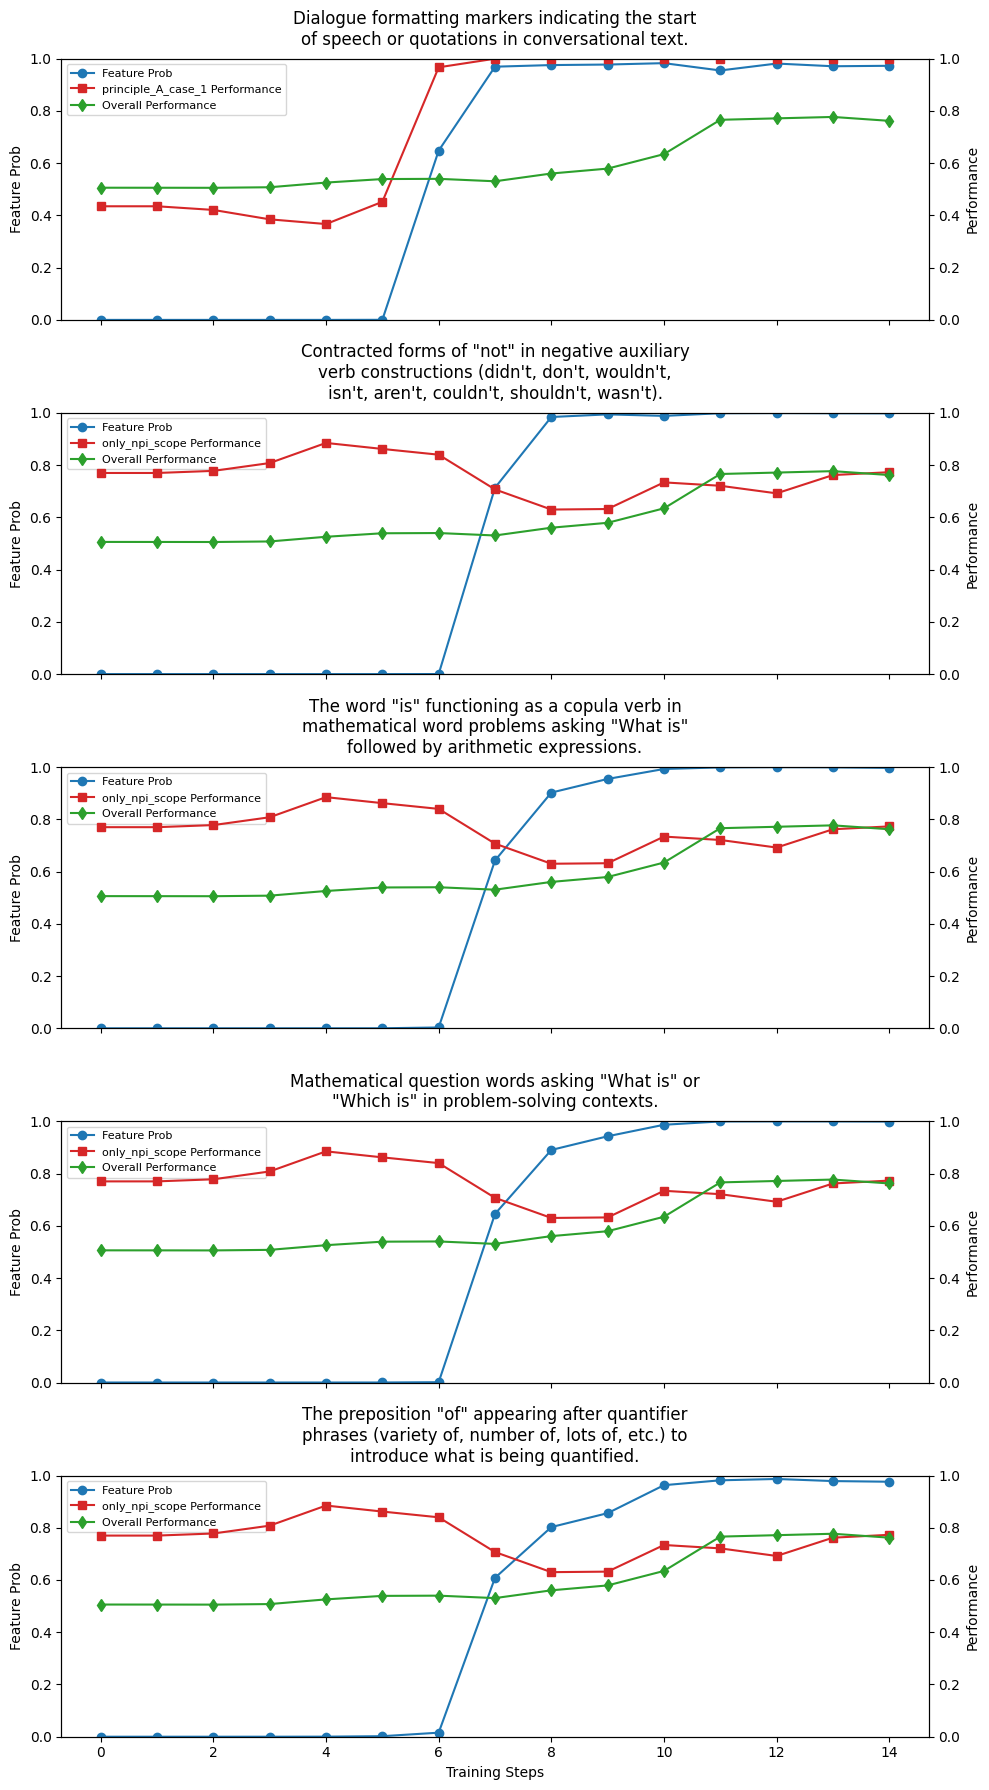

In [85]:
import matplotlib.pyplot as plt
import textwrap

# Number of characters to wrap per line
wrap_width = 50

# Sort by specificity descending and take top 5
top5 = features_df.sort_values("specificity", ascending=False).head(5)

# Assume all have the same number of checkpoints
steps = range(len(top5.iloc[0]["median_probs"]))

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 18), sharex=True)

for i, (_, row) in enumerate(top5.iterrows()):
    ax1 = axes[i]
    ax1.plot(steps, row["median_probs"], color='tab:blue', marker='o', label='Feature Prob')
    ax1.set_ylabel('Feature Prob')
    ax1.set_ylim(0, 1)
    
    ax2 = ax1.twinx()
    
    performances = []
    for model in model_names:
        val = subset_performance_data.get(model, {}).get(row["max_corr_subset"], None)
        performances.append(val/100.0 if val is not None else None)
    
    ax2.plot(steps, performances, color='tab:red', marker='s', label=f'{row["max_corr_subset"]} Performance')
    ax2.plot(steps, row["overall_performance"], color='tab:green', marker='d', label='Overall Performance')
    
    ax2.set_ylabel('Performance')
    ax2.set_ylim(0, 1)
    
    # Wrap feature description automatically
    wrapped_title = "\n".join(textwrap.wrap(row["description"], width=wrap_width))
    ax1.set_title(wrapped_title, fontsize=12, pad=10)
    
    # Legend for each subplot
    lines, labels = ax2.get_legend_handles_labels()
    lines1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(lines1 + lines, labels1 + labels, loc='upper left', fontsize=8)

axes[-1].set_xlabel('Training Steps')
plt.tight_layout()



plt.savefig(f"top5_specificity_features_pythia_{model}.png", dpi=300)


In [86]:
features_df.columns

Index(['feature_id', 'description', 'winning_rank', 'model',
       'sample_centroid_cos_sim', 'avg_ranks', 'avg_probs', 'median_probs',
       'lower_errors', 'higher_errors', 'mean_probs', 'std_probs',
       'feature_performance', 'overall_performance', 'trend_ranks',
       'trend_avg_probs', 'trend_median_probs', 'jump_ranks_value',
       'jump_ranks_idx', 'jump_avg_probs_value', 'jump_avg_probs_idx',
       'jump_median_probs_value', 'jump_median_probs_idx', 'range_ranks',
       'range_avg_probs', 'range_median_probs', 'max_error', 'pearson_corr',
       'spearman_corr', 'residual_pearson_corr', 'residual_spearman_corr',
       'feat_perf_vs_probs_pearson', 'feat_perf_vs_probs_spearman',
       'feat_perf_vs_overall_pearson', 'feat_perf_vs_overall_spearman',
       'feat_perf_vs_probs_residual_pearson',
       'feat_perf_vs_probs_residual_spearman',
       'feat_perf_vs_overall_residual_pearson',
       'feat_perf_vs_overall_residual_spearman', 'has_performance_data',
       's

In [87]:
features_df["max_prob_acquired"] = features_df["median_probs"].apply(lambda x: max(x))
features_df["not_acquired"] = features_df["max_prob_acquired"] < 0.5

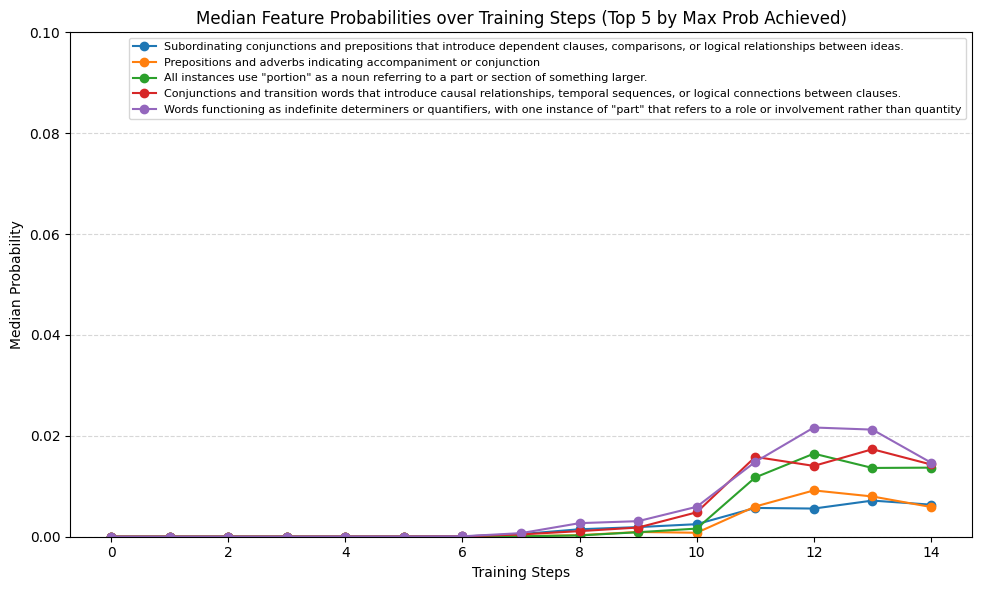

In [88]:
import matplotlib.pyplot as plt

# Sort dataframe by max_prob_acquired ascending and take top 5
top5 = features_df[(features_df["trend_median_probs"] == "increasing") & (features_df["not_acquired"])].sort_values("max_prob_acquired", ascending=True).head(5)

# Assume all have the same number of checkpoints
steps = range(len(top5.iloc[0]["median_probs"]))

plt.figure(figsize=(10, 6))

# Plot each feature
for _, row in top5.iterrows():
    plt.plot(steps, row["median_probs"], marker='o', label=row["description"])

plt.xlabel("Training Steps")
plt.ylabel("Median Probability")
plt.title("Median Feature Probabilities over Training Steps (Top 5 by Max Prob Achieved)")
plt.ylim(0, 0.1)
plt.legend(fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f"top5_max_prob_achieved_features_{model}.png", dpi=300)
